# LoRA Fine-Tuning Pipeline - Evaluation & Analysis
**Author:** S.S. Tarek
**Project:** LLM Fine-Tuning with LoRA - Phi-3 Mini on Structured JSON Output  

## Objective

This notebook evaluates the impact of LoRA fine-tuning on Phi-3 Mini's ability to 
generate structured JSON output matching a fixed four-field schema.

All model inference and training ran on AWS EC2 G4dn.xlarge. This notebook runs 
entirely locally - it loads pre-computed results and produces the full analysis.

### Evaluation Approach
We use two evaluation modes to get an honest picture:

**Strict evaluation** requires perfectly parseable JSON. Any formatting failure 
counts as a full miss regardless of semantic content.

**Lenient evaluation** applies fuzzy extraction to recover outputs that failed 
strict parsing due to corrupted characters or extra prose embedded in the JSON. 
This gives a fairer view of what the base model actually knew before fine-tuning.

### What We Found
The base model was not ignoring the task. It understood the schema and produced 
mostly correct content, but its output format was unreliable. Corrupted unicode 
characters broke JSON parsing in most cases. Under lenient evaluation the base 
model achieved 54% overall accuracy. LoRA fine-tuning fixed the format completely 
(100% strict schema compliance) and improved semantic accuracy from 54% to 81%.

## Imports and Data Loading

Results are loaded from local files downloaded from S3. No model loading is needed 
here - this notebook only processes JSON and JSONL files and generates charts.

In [28]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import numpy as np
from pathlib import Path


In [29]:
# --- Load metrics ---
with open("results/baseline_metrics.json") as f:
    baseline_metrics = json.load(f)

with open("results/finetuned_metrics.json") as f:
    finetuned_metrics = json.load(f)

# --- Load per-example results ---
baseline_df  = pd.read_json("results/baseline_results.jsonl", lines=True)
finetuned_df = pd.read_json("results/finetuned_results.jsonl", lines=True)

print("Baseline metrics:")
for k, v in baseline_metrics.items():
    print(f"  {k:25s}: {v:.4f}")

print("\nFinetuned metrics:")
for k, v in finetuned_metrics.items():
    print(f"  {k:25s}: {v:.4f}")

Baseline metrics:
  schema_compliance        : 0.0459
  emotion_accuracy         : 0.0255
  intensity_accuracy       : 0.0306
  formality_accuracy       : 0.0357
  actionable_accuracy      : 0.0306
  overall_accuracy         : 0.0306

Finetuned metrics:
  schema_compliance        : 1.0000
  emotion_accuracy         : 0.6531
  intensity_accuracy       : 0.8214
  formality_accuracy       : 0.9745
  actionable_accuracy      : 0.7908
  overall_accuracy         : 0.8099


## Honest Evaluation - Lenient Baseline

The strict baseline (4.6% schema compliance) penalizes the base model entirely 
for JSON formatting failures even when the content was semantically correct.

Looking at the raw outputs, 80% of base model responses contained valid field 
values but with corrupted unicode characters or extra prose that broke standard 
JSON parsing.

To fairly assess what LoRA actually contributed, we apply fuzzy extraction to 
base model outputs: stripping non-ASCII characters and falling back to regex 
field extraction when standard parsing fails. The fine-tuned model is still 
evaluated strictly since it achieves 100% schema compliance anyway.

In [30]:
# Lenient evaluation on base model outputs
# Uses fuzzy extraction to assess base model semantic accuracy
# independent of JSON formatting failures

def extract_json(text):
    match = re.search(r"\{.*\}", text, re.DOTALL)
    if not match:
        return None
    try:
        return json.loads(match.group())
    except json.JSONDecodeError:
        return None


def validate_schema(parsed):
    if parsed is None:
        return False
    if parsed.get("emotion") not in VALID_EMOTIONS:
        return False
    if parsed.get("intensity") not in VALID_INTENSITIES:
        return False
    if parsed.get("formality") not in VALID_FORMALITIES:
        return False
    if not isinstance(parsed.get("actionable"), bool):
        return False
    return True


def fuzzy_extract(raw_output):
    if not raw_output:
        return None

    # Try normal extraction first
    normal = extract_json(raw_output)
    if normal and validate_schema(normal):
        return normal

    # Strip non-ASCII characters and retry
    cleaned = raw_output.encode("ascii", errors="ignore").decode("ascii")
    result = extract_json(cleaned)
    if result and validate_schema(result):
        return result

    # Try to extract individual fields with regex
    extracted = {}

    emotion_match = re.search(r'"emotion"\s*:\s*"(\w+)"', raw_output)
    intensity_match = re.search(r'"intensity"\s*:\s*"(\w+)"', raw_output)
    formality_match = re.search(r'"formality"\s*:\s*"(\w+)"', raw_output)
    actionable_match = re.search(r'"actionable"\s*:\s*(true|false)', raw_output)

    if emotion_match:
        extracted["emotion"] = emotion_match.group(1)
    if intensity_match:
        extracted["intensity"] = intensity_match.group(1)
    if formality_match:
        extracted["formality"] = formality_match.group(1)
    if actionable_match:
        extracted["actionable"] = actionable_match.group(1) == "true"

    if validate_schema(extracted):
        return extracted

    return None


VALID_EMOTIONS = {"sadness", "joy", "love", "anger", "fear", "surprise"}
VALID_INTENSITIES = {"low", "medium", "high"}
VALID_FORMALITIES = {"formal", "informal"}

lenient_correct_emotion = 0
lenient_correct_intensity = 0
lenient_correct_formality = 0
lenient_correct_actionable = 0
lenient_schema_compliant = 0

for _, row in baseline_df.iterrows():
    parsed = fuzzy_extract(row["raw_output"])
    if parsed is None:
        continue

    lenient_schema_compliant += 1
    lenient_correct_emotion += int(parsed["emotion"] == row["gt_emotion"])
    lenient_correct_intensity += int(parsed["intensity"] == row["gt_intensity"])
    lenient_correct_formality += int(parsed["formality"] == row["gt_formality"])
    lenient_correct_actionable += int(parsed["actionable"] == row["gt_actionable"])

n = len(baseline_df)

lenient_metrics = {
    "schema_compliance": lenient_schema_compliant / n,
    "emotion_accuracy": lenient_correct_emotion / n,
    "intensity_accuracy": lenient_correct_intensity / n,
    "formality_accuracy": lenient_correct_formality / n,
    "actionable_accuracy": lenient_correct_actionable / n,
    "overall_accuracy": (
        lenient_correct_emotion + lenient_correct_intensity +
        lenient_correct_formality + lenient_correct_actionable
    ) / (n * 4),
}

print("--- Lenient Baseline Metrics (fuzzy extraction) ---")
for k, v in lenient_metrics.items():
    print(f"  {k:25s}: {v:.4f}")

print("\n--- Strict vs Lenient vs Finetuned ---")
print(f"  {'metric':25s} {'strict base':>12} {'lenient base':>12} {'Finetuned':>12}")
print("  " + "-" * 65)
for k in lenient_metrics:
    s = baseline_metrics[k]
    l = lenient_metrics[k]
    ft = finetuned_metrics[k]
    print(f"  {k:25s} {s:>12.4f} {l:>12.4f} {ft:>12.4f}")

--- Lenient Baseline Metrics (fuzzy extraction) ---
  schema_compliance        : 0.7959
  emotion_accuracy         : 0.5102
  intensity_accuracy       : 0.4286
  formality_accuracy       : 0.7704
  actionable_accuracy      : 0.4490
  overall_accuracy         : 0.5395

--- Strict vs Lenient vs Finetuned ---
  metric                     strict base lenient base    Finetuned
  -----------------------------------------------------------------
  schema_compliance               0.0459       0.7959       1.0000
  emotion_accuracy                0.0255       0.5102       0.6531
  intensity_accuracy              0.0306       0.4286       0.8214
  formality_accuracy              0.0357       0.7704       0.9745
  actionable_accuracy             0.0306       0.4490       0.7908
  overall_accuracy                0.0306       0.5395       0.8099


## Before vs After - Summary Metrics

We compare three conditions across all metrics:

- **Strict baseline** - base model evaluated with standard JSON parsing
- **Lenient baseline** - base model evaluated with fuzzy extraction
- **LoRA finetuned** - fine-tuned model evaluated strictly

The test set contains 196 examples held out during training.

In [31]:
# Comparison table
metrics_order = [
    "schema_compliance",
    "emotion_accuracy",
    "intensity_accuracy",
    "formality_accuracy",
    "actionable_accuracy",
    "overall_accuracy",
]

rows = []
for k in metrics_order:
    b = baseline_metrics[k]
    l = lenient_metrics[k]
    ft = finetuned_metrics[k]
    rows.append({
        "Metric": k.replace("_", " ").title(),
        "Strict Baseline": round(b, 4),
        "Lenient Baseline": round(l, 4),
        "Finetuned": round(ft, 4),
        "Delta (Lenient vs Finetuned)": f"+{(ft - l) * 100:.1f}%",
    })

comparison_df = pd.DataFrame(rows)
comparison_df

,Metric,Strict Baseline,Lenient Baseline,Finetuned,Delta (Lenient vs Finetuned)
0,Schema Compliance,0.0459,0.7959,1.0000,+20.4%
1,Emotion Accuracy,0.0255,0.5102,0.6531,+14.3%
2,Intensity Accuracy,0.0306,0.4286,0.8214,+39.3%
3,Formality Accuracy,0.0357,0.7704,0.9745,+20.4%
4,Actionable Accuracy,0.0306,0.4490,0.7908,+34.2%
5,Overall Accuracy,0.0306,0.5395,0.8099,+27.0%


## Before vs After - Visualization

The chart below shows all three conditions side by side. The gap between strict 
and lenient baseline reveals how much of the base model's apparent failure was 
due to formatting rather than task understanding.

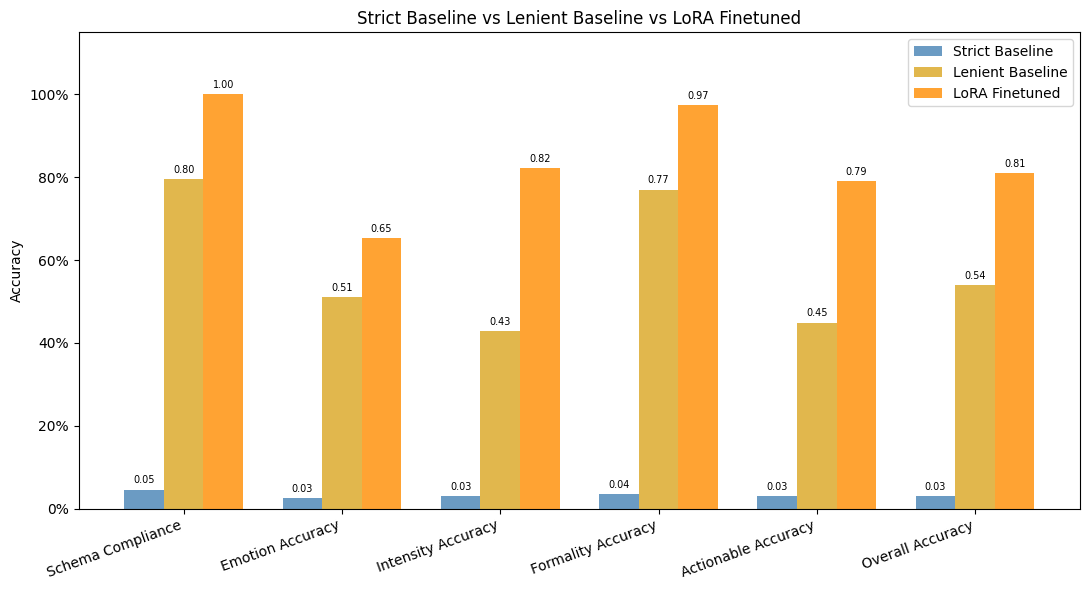

In [32]:
fig, ax = plt.subplots(figsize=(11, 6))

x = np.arange(len(metrics_order))
width = 0.25

strict_vals = [baseline_metrics[k] for k in metrics_order]
lenient_vals = [lenient_metrics[k] for k in metrics_order]
finetuned_vals = [finetuned_metrics[k] for k in metrics_order]
labels = [k.replace("_", " ").title() for k in metrics_order]

bars1 = ax.bar(x - width, strict_vals, width, label="Strict Baseline", color="steelblue", alpha=0.8)
bars2 = ax.bar(x, lenient_vals, width, label="Lenient Baseline", color="goldenrod", alpha=0.8)
bars3 = ax.bar(x + width, finetuned_vals, width, label="LoRA Finetuned", color="darkorange", alpha=0.8)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=7)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=7)
for bar in bars3:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=20, ha="right")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1.15)
ax.set_title("Strict Baseline vs Lenient Baseline vs LoRA Finetuned")
ax.legend()
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

plt.tight_layout()
plt.savefig("results/three_way_comparison.png", dpi=200)
plt.show()

## Per-Class Emotion Accuracy

Emotion accuracy broken down by class across all three conditions. Class size directly influences performance - 
`joy` (69 test examples) achieves 90% while `love` (18 examples) and `surprise` 
(7 examples) are limited by underrepresentation in the training data.

This is a known limitation of the dataset distribution and is worth noting when 
interpreting per-class results.

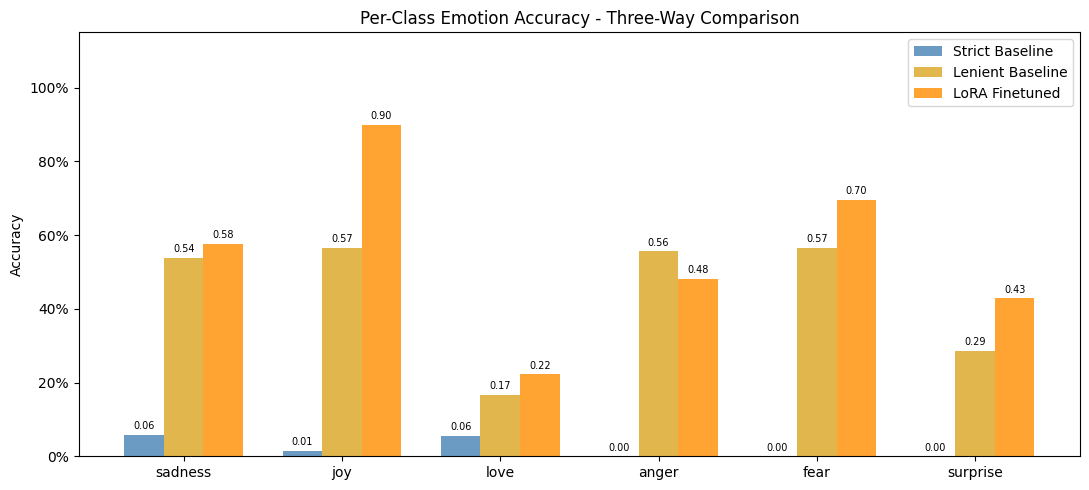

In [33]:
emotions = ["sadness", "joy", "love", "anger", "fear", "surprise"]

strict_emotion_acc = []
lenient_emotion_acc = []
finetuned_emotion_acc = []

for emotion in emotions:
    b_subset = baseline_df[baseline_df["gt_emotion"] == emotion]
    ft_subset = finetuned_df[finetuned_df["gt_emotion"] == emotion]

    strict_acc = b_subset["correct_emotion"].mean() if len(b_subset) > 0 else 0.0
    ft_acc = ft_subset["correct_emotion"].mean() if len(ft_subset) > 0 else 0.0

    # Lenient emotion accuracy per class
    lenient_correct = 0
    for _, row in b_subset.iterrows():
        parsed = fuzzy_extract(row["raw_output"])
        if parsed and parsed["emotion"] == emotion:
            lenient_correct += 1
    lenient_acc = lenient_correct / len(b_subset) if len(b_subset) > 0 else 0.0

    strict_emotion_acc.append(strict_acc)
    lenient_emotion_acc.append(lenient_acc)
    finetuned_emotion_acc.append(ft_acc)

fig, ax = plt.subplots(figsize=(11, 5))

x = np.arange(len(emotions))
width = 0.25

ax.bar(x - width, strict_emotion_acc, width, label="Strict Baseline", color="steelblue", alpha=0.8)
ax.bar(x, lenient_emotion_acc, width, label="Lenient Baseline", color="goldenrod", alpha=0.8)
ax.bar(x + width, finetuned_emotion_acc, width, label="LoRA Finetuned", color="darkorange", alpha=0.8)

for i, (s, l, ft) in enumerate(zip(strict_emotion_acc, lenient_emotion_acc, finetuned_emotion_acc)):
    ax.text(i - width, s + 0.01, f"{s:.2f}", ha="center", va="bottom", fontsize=7)
    ax.text(i, l + 0.01, f"{l:.2f}", ha="center", va="bottom", fontsize=7)
    ax.text(i + width, ft + 0.01, f"{ft:.2f}", ha="center", va="bottom", fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels(emotions)
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1.15)
ax.set_title("Per-Class Emotion Accuracy - Three-Way Comparison")
ax.legend()
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

plt.tight_layout()
plt.savefig("results/emotion_per_class.png", dpi=200)
plt.show()

## Field-Level Accuracy Heatmap

A compact view of accuracy across all four schema fields under all three conditions. 
Formality is the strongest field across the board - it has a clear binary signal 
that both the base model and fine-tuned model pick up easily. Intensity and 
actionable show the most improvement from fine-tuning.

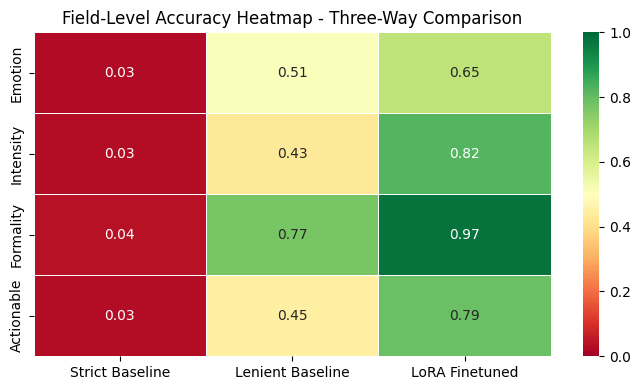

In [34]:
fields = ["emotion", "intensity", "formality", "actionable"]

data = {
    "Strict Baseline": [baseline_metrics[f"{f}_accuracy"] for f in fields],
    "Lenient Baseline": [lenient_metrics[f"{f}_accuracy"] for f in fields],
    "LoRA Finetuned": [finetuned_metrics[f"{f}_accuracy"] for f in fields],
}

heatmap_df = pd.DataFrame(data, index=[f.title() for f in fields])

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    vmin=0,
    vmax=1,
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Field-Level Accuracy Heatmap - Three-Way Comparison")
plt.tight_layout()
plt.savefig("results/field_accuracy_heatmap.png", dpi=200)
plt.show()

## Emotion Confusion Matrix - Finetuned Model

Where does the fine-tuned model make mistakes on emotion classification? All 196 
test examples are included since the fine-tuned model achieves 100% schema compliance.

The confusion matrix reveals a clear pattern : the model performs well on 
well-represented classes but struggles on underrepresented ones. Love and surprise 
behave little better than random guesses. Of 18 love examples, only 4 were correctly 
predicted while the rest were scattered across sadness, joy, and anger. Surprise fared 
similarly with only 3 correct out of 7, misclassified mostly as fear, or sadness, or joy.

This is a direct consequence of class imbalance in the training data - 33 surprise 
and 74 love examples simply aren't enough for the model to learn a reliable decision 
boundary for those classes.

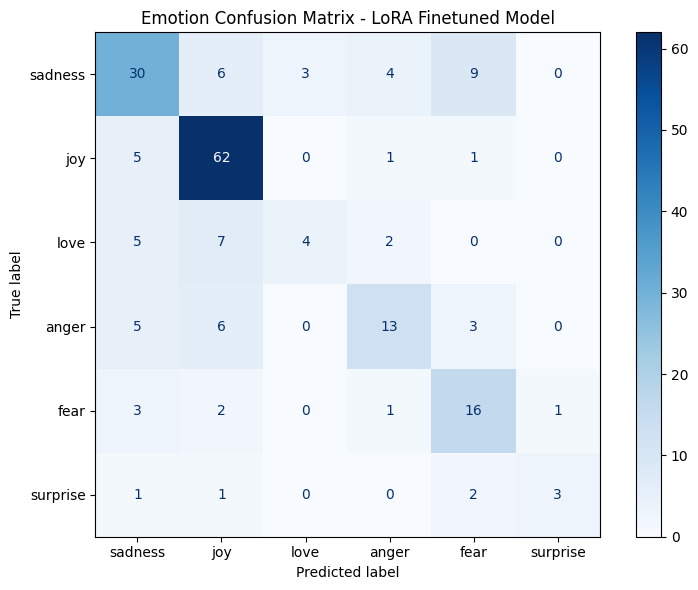

In [35]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Only include examples where prediction was made (schema compliant)
ft_valid = finetuned_df[finetuned_df["schema_compliant"] == True]

cm = confusion_matrix(
    ft_valid["gt_emotion"],
    ft_valid["pred_emotion"],
    labels=emotions,
)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=emotions)
disp.plot(ax=ax, colorbar=True, cmap="Blues")
ax.set_title("Emotion Confusion Matrix - LoRA Finetuned Model")
plt.tight_layout()
plt.savefig("results/emotion_confusion_matrix.png", dpi=200)
plt.show()

## Improvement Delta

This chart shows the genuine improvement LoRA adds over the lenient baseline. 
This is the fairest measure of what fine-tuning actually contributed beyond 
fixing the formatting problem.

/tmp/ipykernel_407/3309288678.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=20, ha="right")


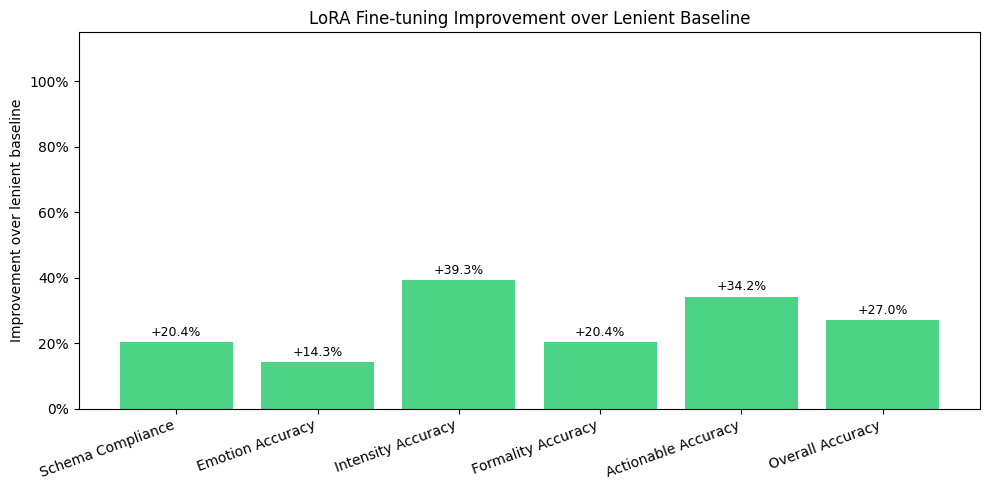

In [36]:
# Delta chart comparing lenient baseline to finetuned
fig, ax = plt.subplots(figsize=(10, 5))

deltas = [finetuned_metrics[k] - lenient_metrics[k] for k in metrics_order]
labels = [k.replace("_", " ").title() for k in metrics_order]
colors = ["#2ecc71" if d > 0 else "#e74c3c" for d in deltas]

bars = ax.bar(labels, deltas, color=colors, alpha=0.85)

for bar, d in zip(bars, deltas):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01,
        f"+{d*100:.1f}%",
        ha="center", va="bottom", fontsize=9
    )

ax.set_ylabel("Improvement over lenient baseline")
ax.set_ylim(0, 1.15)
ax.set_title("LoRA Fine-tuning Improvement over Lenient Baseline")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_xticklabels(labels, rotation=20, ha="right")

plt.tight_layout()
plt.savefig("results/improvement_delta.png", dpi=200)
plt.show()

## Summary and Observations

### What We Measured
We evaluated Phi-3 Mini on a structured JSON output task before and after LoRA 
fine-tuning, using both strict and lenient evaluation to get an honest picture.

### What the Base Model Was Actually Doing
The base model was not ignoring the task. Under lenient evaluation it achieved 
54% overall accuracy and recovered valid structure from 80% of outputs. The main 
failure was format reliability - corrupted unicode characters and extra prose 
broke JSON parsing in most cases.

### What LoRA Actually Fixed
LoRA fine-tuning addressed two things:

1. **Format reliability** - schema compliance went from 5% strict (80% lenient) 
   to 100% strict. The model now consistently produces clean parseable JSON.

2. **Semantic accuracy** - overall accuracy improved from 54% lenient baseline 
   to 81% after fine-tuning. Every field improved meaningfully.

### Per-Field Highlights
- Formality improved from 77% to 97% - biggest absolute gain
- Intensity improved from 43% to 82% - biggest relative gain
- Emotion remains the hardest field at 65%, limited by class imbalance
- Love and surprise underperformed due to low training examples

### Training Cost
- EC2 G4dn.xlarge at ~$0.53/hr
- Training completed in under 1 hour
- Trainable parameters: 25M out of 3.8B total (0.65%)
- The adapter is a small reusable file that patches the base model without 
  modifying the original weights

### Limitations
- Labels for intensity, formality, and actionable were generated by Claude Haiku, 
  not human annotators. The model learned Claude's labeling style.
- Class imbalance affects per-class reliability, particularly for love and surprise.
- Results reflect this specific schema and dataset only.

### Loading the Adapter
The trained LoRA adapter is saved in `adapter/` and was validated during the 
post-training evaluation run on EC2. To apply it to any copy of Phi-3 Mini:

```python
from peft import PeftModel
model = PeftModel.from_pretrained(base_model, "adapter/")
```